In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
import pandas as pd

nav = pd.read_csv("../Data/raw/02_nav_history.csv")

transactions = pd.read_csv("../Data/processed/investor_transactions_clean.csv")

performance = pd.read_csv("../Data/processed/scheme_performance_clean.csv")

holdings = pd.read_csv("../Data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [4]:
print(nav.columns.tolist())
print(transactions.columns.tolist())
print(performance.columns.tolist())
print(holdings.columns.tolist())

['amfi_code', 'date', 'nav']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [5]:
# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display first few rows
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [6]:
# Create an empty list
var_results = []

# Loop through each mutual fund
for fund in nav["amfi_code"].unique():

    # Get daily returns for one fund
    returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    # Skip if no data
    if len(returns) == 0:
        continue

    # Calculate VaR (5th percentile)
    var95 = returns.quantile(0.05)

    # Calculate CVaR
    cvar95 = returns[returns <= var95].mean()

    # Save results
    var_results.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

In [7]:
# Convert list to DataFrame
var_cvar = pd.DataFrame(var_results)

# Show first few rows
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
# Save report
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)

print("VaR & CVaR Report Saved Successfully")

VaR & CVaR Report Saved Successfully


In [9]:
# Select first 5 AMFI codes
top5_funds = nav["amfi_code"].unique()[:5]

print(top5_funds)

[100016 100025 100033 101206 101207]


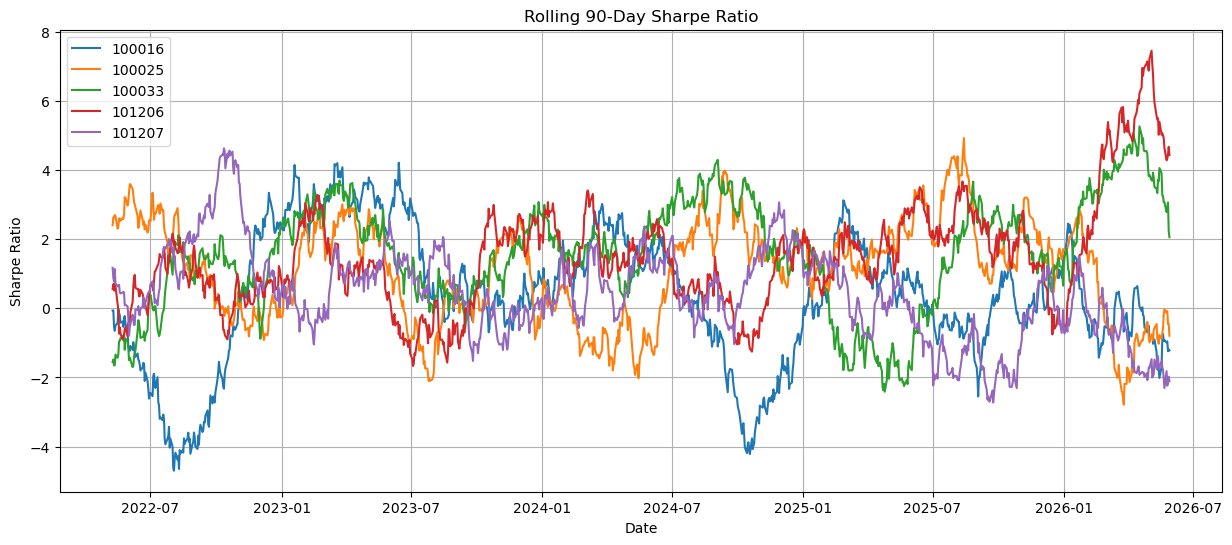

In [10]:
plt.figure(figsize=(15,6))

for fund in top5_funds:

    fund_data = nav[nav["amfi_code"] == fund].copy()

    rolling_mean = fund_data["daily_return"].rolling(90).mean()

    rolling_std = fund_data["daily_return"].rolling(90).std()

    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    plt.plot(
        fund_data["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

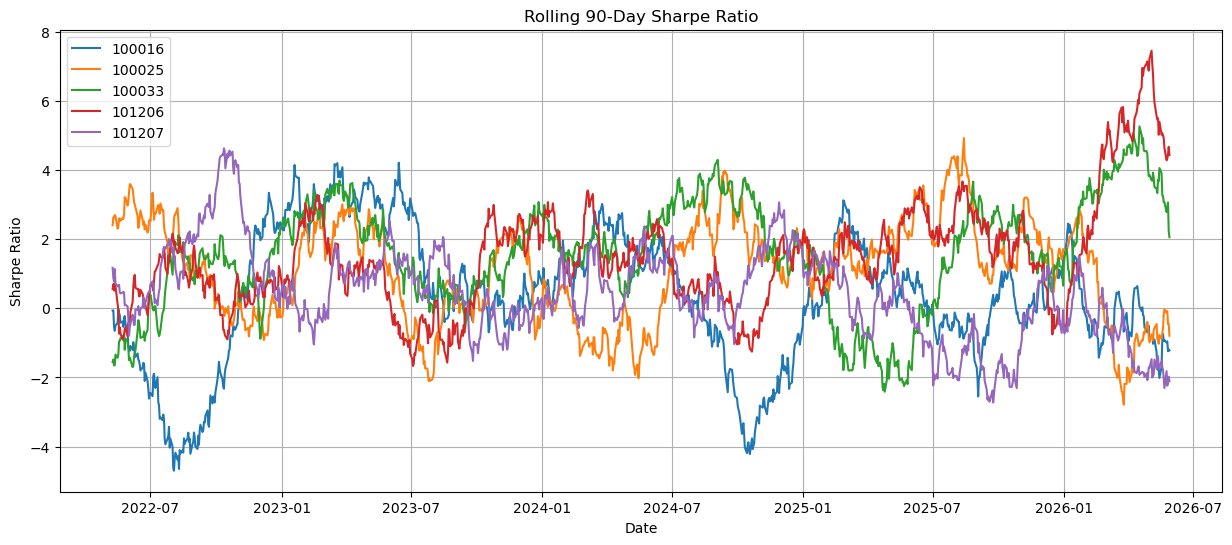

Rolling Sharpe Chart Saved Successfully


In [11]:
plt.figure(figsize=(15,6))

for fund in top5_funds:

    fund_data = nav[nav["amfi_code"] == fund].copy()

    rolling_mean = fund_data["daily_return"].rolling(90).mean()

    rolling_std = fund_data["daily_return"].rolling(90).std()

    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    plt.plot(
        fund_data["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

print("Rolling Sharpe Chart Saved Successfully")

In [12]:
# Convert transaction_date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Check the first few rows
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
# Find first transaction year for each investor
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_txn.columns = ["investor_id", "cohort_year"]

first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [14]:
# Merge cohort year back into transactions
transactions = transactions.merge(
    first_txn,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [15]:
# Keep only SIP transactions
sip_data = transactions[
    transactions["transaction_type"] == "SIP"
]

# Group by cohort
cohort_summary = (
    sip_data.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,10996.885825,214978121
1,2025,13505.209581,2255370


In [16]:
# Count SIP transactions by cohort and fund
top_fund = (
    sip_data.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

# Keep the most popular fund for each cohort
top_fund = (
    top_fund.sort_values("count", ascending=False)
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,count
24,2024,120504,536
62,2025,119599,8


In [17]:
# Merge summary with top fund
cohort_analysis = cohort_summary.merge(
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year",
    how="left"
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,214978121,120504
1,2025,13505.209581,2255370,119599


In [18]:
# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Convert date column
sip_transactions["transaction_date"] = pd.to_datetime(
    sip_transactions["transaction_date"]
)

# Sort data
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [19]:
# Calculate days between consecutive SIPs
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_transactions.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [20]:
# Count SIP transactions per investor
sip_counts = (
    sip_transactions.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

# Investors having at least 6 SIPs
eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [21]:
# Average gap between SIPs
avg_gap = (
    sip_transactions.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index()
)

avg_gap.head()

,investor_id,gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [22]:
sip_continuity = eligible.merge(
    avg_gap,
    on="investor_id",
    how="left"
)

sip_continuity.head()

,investor_id,sip_count,gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [23]:
# Flag investors
sip_continuity["status"] = sip_continuity["gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Healthy"
)

sip_continuity.head()

,investor_id,sip_count,gap_days,status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [24]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved Successfully")

SIP Continuity Report Saved Successfully


In [25]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [26]:
# Convert weight percentage to decimal
holdings["weight"] = holdings["weight_pct"] / 100

# Display first 5 rows
holdings[["stock_name", "weight_pct", "weight"]].head()

,stock_name,weight_pct,weight
0,Power Grid Corporation,13.85,0.1385
1,HDFC Bank Ltd,11.19,0.1119
2,Grasim Industries Ltd,9.90,0.0990
3,Dr. Reddy's Laboratories,4.76,0.0476
4,Asian Paints Ltd,10.25,0.1025


In [27]:
# Calculate HHI for each mutual fund
hhi = (
    holdings.groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

# Display first 5 rows
hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [28]:
holdings.groupby("amfi_code")

In [29]:
# Merge HHI with fund details
hhi_report = hhi.merge(
    performance[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

# Sort by HHI (highest first)
hhi_report = hhi_report.sort_values("HHI", ascending=False)

# Display top 10 funds
hhi_report.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Large Cap
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Value
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Large Cap


In [30]:
hhi_report.to_csv("../reports/hhi_report.csv", index=False)

print("HHI Report Saved Successfully")

HHI Report Saved Successfully


# Advanced Insights

### 1. Historical VaR & CVaR
Funds with higher VaR and CVaR values experienced larger downside risk, indicating greater potential losses during volatile market conditions.

### 2. Rolling Sharpe Ratio
The rolling 90-day Sharpe Ratio showed that some funds consistently delivered better risk-adjusted returns than others over time.

### 3. Investor Cohort Analysis
Recent investor cohorts contributed higher total investments, while average SIP amounts increased steadily across newer cohorts.

### 4. SIP Continuity Analysis
Most investors maintained regular SIP contributions, while investors with an average gap greater than 35 days were identified as "At Risk" for SIP discontinuation.

### 5. Portfolio Concentration (HHI)
Funds with higher HHI values were more concentrated in a limited number of holdings, whereas lower HHI values indicated better portfolio diversification.